#  <span style="color:blue">Tutorial - Particle Filter</span>

This tutorial implements a Particle filter (PF) for a differential drive robot using Python. We cover:
- Understand how uncertainty modelling is achieved in the PF, and the impact of process and measurement noise parameters
- Be able to implement and apply a PF to a simple robotic scenario

Classes and functions defined in this section are also contained in the course libraries `model_feeg6043.py` and `math_feeg6043.py` and `plot_feeg6043.py` libraries, where we will also use function already defined in these libraries from earlier in the course. The figure below gives an overview of what we will cover to implement the PF.

<img src="images/A2_2_Tutorial_Overview.png" alt="Tutorial Overview" width="800px" align="center"/>    

## Overview

Particle filters implement discrete recursive Bayes state estimation. They consist of a set of $N$ particles, usually many hundreds, where where each individual particle represents a state hypothesis $\mathbf{x}_k$ and weight $\mathbf{w}_k$ that tracks how consistent each particle is with sensor measurements:
$$\chi_k = \left\{[\mathbf{x}^{[i]}_k, \mathbf{w}^{[i]}_k]\right\}_{i=1,...,N}$$

The belief of each state is modelled through a weighted particle density, where a high weighted density of particles indicates a more likely value of each states. 

To limit computational costs, particle filters (PFs) are typically used only for states with highly non-linear probability distributions, where they offer the most advantage. States with milder non-linearity are handled by other methods, such as the Extended Kalman Filter (EKF). This selective allocation of computational effort is known as Rao-Blackwellization. Other practical considerations, such as deciding when to transfer information from weights to states, are also crucial for building effective PFs.

## <span style="color:red">1. Initial states and weights</span>

Below we define a class to generate $N$ particles with states:

$$ \mathbf{x} = (N, E, \gamma , \dot x, \dot \gamma) $$

where,

* $N$ is the northing position (frame $e$) in metres
* $E$ is the easting position (frame $e$) in metres
* $\gamma$ is the heading (frame $e$) in radians
* $\dot x$ is the forward speed (frame $b$) in m/s
* $\dot \gamma$ is the angular rate (frame $b$ and $e$) rad/s

and weights initially uniform across all particles at $\mathbf{w} = 1/N$.

In [1]:
import numpy as np
import scipy
import copy
from matplotlib import cm
import matplotlib.pyplot as plt
from plot_feeg6043 import plot_cumsum, plot_systematic_resample, plot_pf_trajectory
from model_feeg6043 import initialise_particle_distribution, pf_measurement_probability, kde_probability, pf_normalise_weights, pf_update, neff, pf_resample, systematic_resample, kde_probability
from math_feeg6043 import wrapped_mean, wrapped_std

plt.rcParams.update({'font.size': 14})
plt.rcParams["figure.figsize"] = (5,3) #make plots look nice
plt.rcParams["figure.dpi"] = 150 #make plots look nice

class Particles:
    def __init__(self, N):
        self.N = N
        self.northings = np.array([None] * N)  # State - to be estimated
        self.eastings = np.array([None] * N)   # State - to be estimated
        self.gamma = np.array([None] * N)      # State provided with noise
        self.x_dot = np.array([None] * N)       # State provided with noise
        self.gamma_dot = np.array([None] * N)      # State provided with noise
        self.weight = np.ones(N) / float(N)    # Particle weights     
        
    def __str__(self):
        return "northings: " + str(self.northings) + "\neastings: " + str(self.eastings) + "\nweights: " + str(self.weight)

Below we create a tiny set of 3 particles and access the northings, eastings and weight parameter of the class instance.

In [2]:
particles = Particles(3)

print('To access the particle positions type particles.northings and particles.eastings:')
print(particles.northings, particles.eastings)

print('To access the particle weights type particles.weight:')
print(particles.weight)

print('Can print all the above:')
print(particles)

To access the particle positions type particles.northings and particles.eastings:
[None None None] [None None None]
To access the particle weights type particles.weight:
[0.33333333 0.33333333 0.33333333]
Can print all the above:
northings: [None None None]
eastings: [None None None]
weights: [0.33333333 0.33333333 0.33333333]


<div class="alert alert-block alert-info">
    <b>States and Rao-Blackwellisation:</b> Each particle has a full set of states, but  only northings and eastings will be used for measurement updates (i.e., computation of weights, basis for resampling). Other states are only used in the prediction step and can use measurement data as part of the motion model (e.g., heading, speed sensors) where measurement noise can be randomly sampled for each particle to capture the range of possible motion. This could equally be done using an EKF, drawing sampling noise from each state's uncertainty.
</div>

### <span style="color:red">Initialise the states</span>

The particles have equal weights but they don't have any state information. To populate an initial particle distribution, we can sample these from a bounded uniform distribution.

```
np.random.uniform(low, high, N)
```

which takes `N` samples from the interval 
> low $\leq$ x <  high 

where all values have the same probability of being sampled. In practise we normally have some rough idea of the robots starting location, and some range within which we belief the robot to be. Therefore it makes sense to draw from a constant range of some centre point. We can do this using our polar to cartesian transformation from an earlier tutorial.

We do something similar for the initial heading. If there was no information, this could also be sampled from the full 360 degrees but in practise a compass or initial measurement would be used to give a sensible value

In [3]:
from math_feeg6043 import polar2cartesian

def initialise_particle_distribution(particles, centre=[0, 0], radius = 1, heading = 0):

    # sample angles and ranges
    theta = np.random.uniform(0, np.deg2rad(360), particles.N)
    r = np.sqrt(np.random.uniform(0, 1, particles.N)) * radius    

    # convert to cartesian    
    northings, eastings = polar2cartesian(r,theta)
    
    # add centre offset
    particles.northings  = northings + centre[0]
    particles.eastings = eastings + centre[1]
    
    # particles could be pointing anywhere
    particles.gamma = np.random.uniform(heading - np.deg2rad(10) , heading + np.deg2rad(10), particles.N)
    
initialise_particle_distribution(particles)
print(particles)

northings: [-0.94285006 -0.24079633 -0.5213278 ]
eastings: [-0.20770567  0.29266809 -0.3132974 ]
weights: [0.33333333 0.33333333 0.33333333]


As we increase the number of particles $N$, we expect their distribution to approach the theoretical distribution, which for a circle of radius r would be:

$$ N_{b} = N \dfrac{2\sqrt{(r^2 - x^2)}}{\pi r^2} \Delta x$$

where $\Delta x = 2r/b$ is width of each bin along a cartesian axis $x$, and $N_b$ is the number of particles in each bin and $b$ is the number of bins. Try varying $N$ to get a feel for how many particles are needed to get a good approximation.

<div class="alert alert-block alert-info">
    <b>Task 1:</b> Run the code below for 50 particles <br>
    <b>Task 2:</b> Run the code below for 100 particles <br>
    <b>Task 3:</b> Run the code below for 1,000 particles <br>
    <b>Task 4:</b> Run the code below for 10,000 particles <br>    
</div>

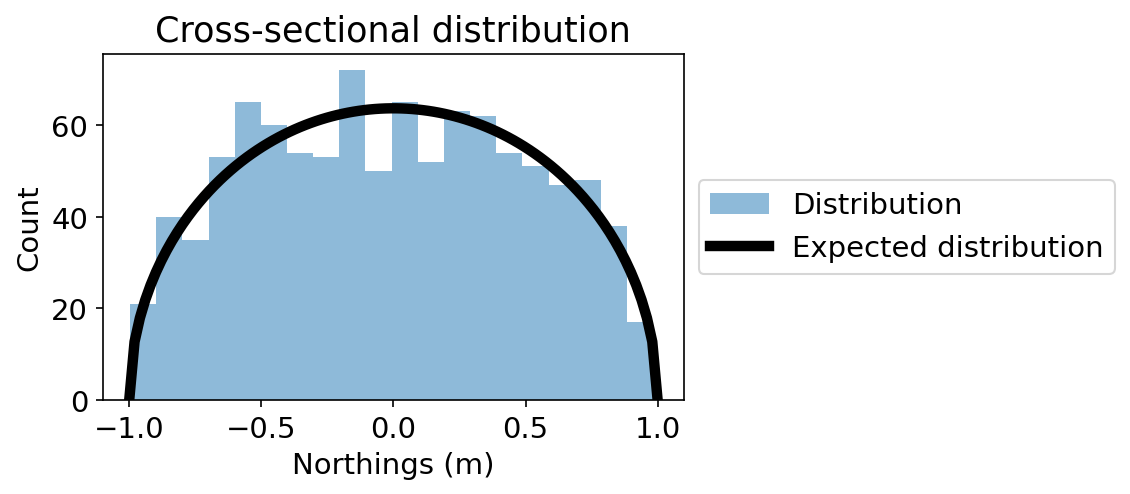

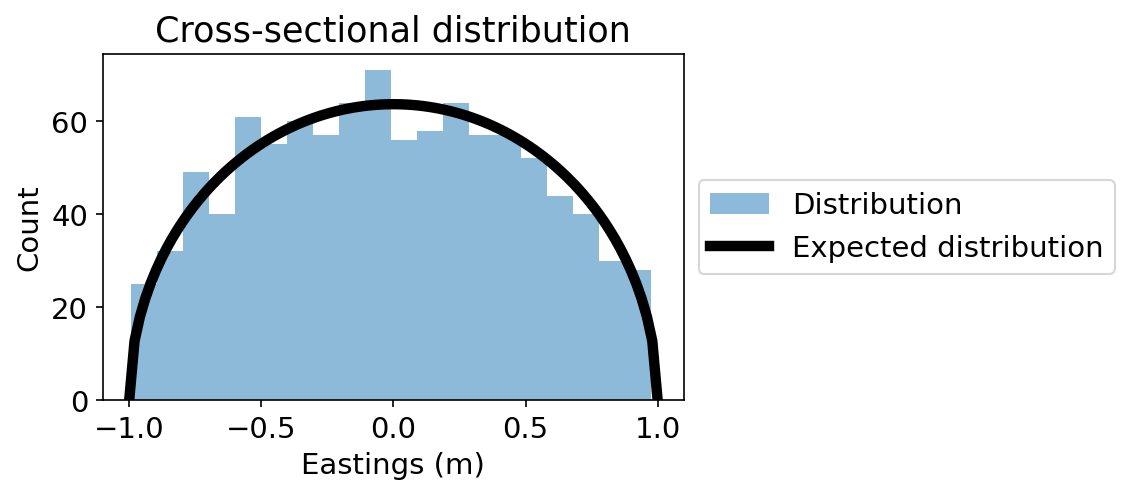

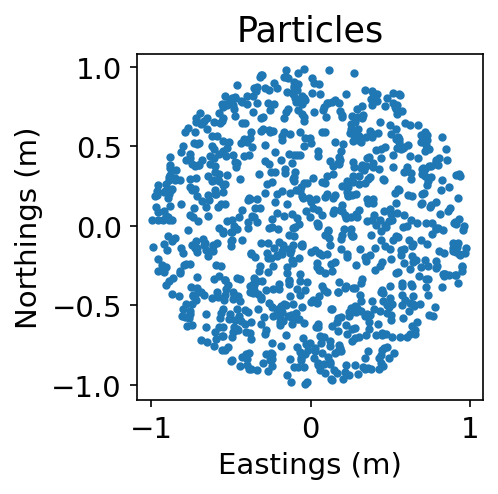

In [6]:
N=1000
centre = [0,0]
radius = 1

particles = Particles(N)
initialise_particle_distribution(particles, centre, radius)

# Code below plots the expected distribution
nbins = 20 #number of histogram bins

# expected distribution
x = np.linspace(centre[1]-radius,centre[1]+radius,100)
Nb = N*2*(np.sqrt(radius**2 - x**2)/(np.pi*radius**2))*(2*radius/nbins)


plt.figure(); plt.hist(particles.northings, alpha=.5, label="Distribution", bins=nbins)
plt.plot(x, Nb, 'k',  linewidth = 5, label="Expected distribution")
plt.title("Cross-sectional distribution"); plt.xlabel("Northings (m)"); plt.ylabel("Count"); plt.legend()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)); plt.show()

plt.figure(); plt.hist(particles.eastings, alpha=.5, label="Distribution", bins=nbins)
plt.plot(x, Nb,'k', linewidth = 5, label="Expected distribution")
plt.title("Cross-sectional distribution"); plt.xlabel("Eastings (m)"); plt.ylabel("Count"); plt.legend()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)); plt.show()

plt.figure(); plt.plot(particles.eastings, particles.northings, '.'); 
plt.axis('square')
plt.title("Particles"); plt.xlabel("Eastings (m)"); plt.ylabel("Northings (m)"); plt.show()

## <span style="color:blue">2. Predict next state</span>

__Progress using a motion model__: Each particle's previous state hypothesis in $\chi_{k-1}$ is progressed through a motion model:

$$ \overline{\mathbf{x}}^{[n]}_{k} = f (\mathbf{x}^{[n]}_{k-1}, \mathbf{u}_{k})+v_k $$

All particles experience the same measurements and control $\mathbf{u}_k$, but noise is added to each state as a discrete value, randomly sampled from the state noise $v_k$ (can be Gaussian or non-Gaussian ). Each particle $\overline{\mathbf{\chi}}_k$ represents a possible state hypotheses.

$$\overline{\mathbf{x}}^{[n]}_k \sim p(\mathbf{x}_k|\mathbf{x}^{[n]}_{k-1},\mathbf{u}_k)$$

where the distribution of all particles represents the prior belief $\overline{bel}(\mathbf{x}_k)$. This step does not affect $w^{[n]}_k$. 

Our discrete motion model uses heading as an input, where this can be measured by a sensor or or can be progressed from the previous particle state. 
We don't explicitely update particles as part of our Rao-Blackwellisation to reduce the number of particles we need. The base of the motion model is the kinematic motion model for **twist motion** derived in A1.2 and used in previous tutorials. It is `rigid_body_kinematics` in `model_feeg6043`:

\begin{eqnarray}
\mathbf{x}_{k} = f(\mathbf{x}_{k-1},\mathbf{u}_{k}) = \left\lbrace \begin{array}{l}
f_0(\mathbf{x}_{k-1},\mathbf{u}_{k}) = N_{k} &=& N_{k-1}  -\frac{\dot{x}_k}{\dot{\gamma}_k} \sin \gamma_{k-1} +\frac{\dot{x}_k}{\dot{\gamma}_k}  \sin (\gamma_{k-1} + {\dot{\gamma}_k}\Delta t_k) \\
f_1(\mathbf{x}_{k-1},\mathbf{u}_{k}) = E_{k} &=& E_{k-1} + \frac{\dot{x}_k}{\dot{\gamma}_k} \cos \gamma_{k-1} - \frac{\dot{x}_k}{\dot{\gamma}_k} \cos (\gamma_{k-1} + \dot{\gamma}_k\Delta t_k) \\
f_2(\mathbf{x}_{k-1},\mathbf{u}_{k}) = \gamma_{k} &=&  \gamma_{k-1} + \dot \gamma_{k}\Delta t_k \\
f_3(\mathbf{x}_{k-1},\mathbf{u}_{k}) = \dot x_{k} &=& v \\
f_4(\mathbf{x}_{k-1},\mathbf{u}_{k}) = \dot \gamma_{k} &=& \omega \end{array} \right. 
\end{eqnarray}


In [7]:
from math_feeg6043 import Vector, Matrix, Identity, Inverse, eigsorted, gaussian, l2m
from model_feeg6043 import rigid_body_kinematics

def discrete_motion_model(particles, gamma, u, dt, process_noise):
    
        g_std = np.sqrt(process_noise[0]) # we choose to use variance, to make inputs equivalent to EKF
        x_dot_std = np.sqrt(process_noise[1])
        g_dot_std = np.sqrt(process_noise[2])
        
        for i in range(particles.N):

            p = Vector(3)
            
            # noise is not added to the location of the particles as the distribution already represents the noise and this is what our PF will update based on sensor observations
            p[0] = particles.northings[i]
            p[1] = particles.eastings[i]

            # We treat the other states as auxilliary (Rao-Blackwellisation), where noise is random sampled from a distribution and added   
            if gamma != None: p[2] = gamma + np.random.normal(scale = g_std) % (2*np.pi)  
            else: p[2] = particles.gamma[i] + np.random.normal(scale = g_std) % (2*np.pi)  
            
            u_noise = Vector(2)
            u_noise[0] = u[0] + np.random.normal(scale=x_dot_std)
            u_noise[1] = u[1] + np.random.normal(scale=g_dot_std)   
            
            # note rigid_body_kinematics already handles the exception dynamics of w=0
            p = rigid_body_kinematics(p,u_noise,dt)    
    
            # update the particles and store the information
            particles.northings[i] = p[0]
            particles.eastings[i] = p[1]
            particles.gamma[i] = p[2]            
            particles.x_dot[i] = u_noise[0]
            particles.gamma_dot[i] = u_noise[1]                        

Put some values in, make noise parameters large to check the expected behaviour
> Run the simulation with control to move north direction at 0.5m/s for 10s. Change the std values and compare the predicted distribution

<div class="alert alert-block alert-info">
    <b>Task 1:</b> Try g_std = 1 deg, x_dot_std = 0.1m/s, g_dot_std = 1 deg/s <br>
    <b>Task 2:</b> Try g_std = 30 deg, x_dot_std = 0.1m/s, g_dot_std = 1 deg/s  <br>
    <b>Task 3:</b> Try g_std = 1 deg, x_dot_std = 0.1m/s, g_dot_std = 5 deg/s  <br>
    <b>Task 4:</b> Try g_std = 1 deg, x_dot_std = 1m/s, g_dot_std = 1 deg/s  <br>
</div>

C:\Users\skyem\AppData\Local\Temp\ipykernel_6264\4218822168.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  particles.northings[i] = p[0]
C:\Users\skyem\AppData\Local\Temp\ipykernel_6264\4218822168.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  particles.eastings[i] = p[1]
C:\Users\skyem\AppData\Local\Temp\ipykernel_6264\4218822168.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  particles.gamma[i] = p[2]


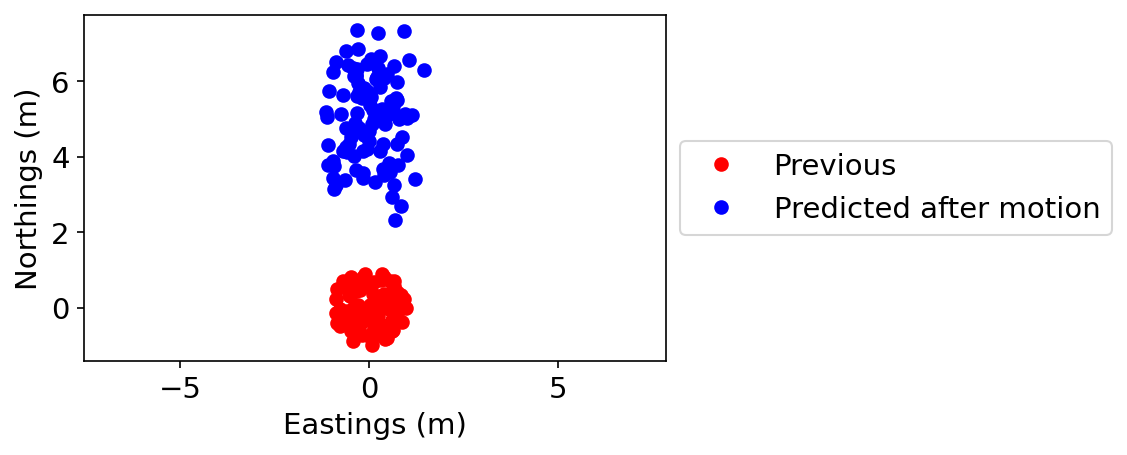

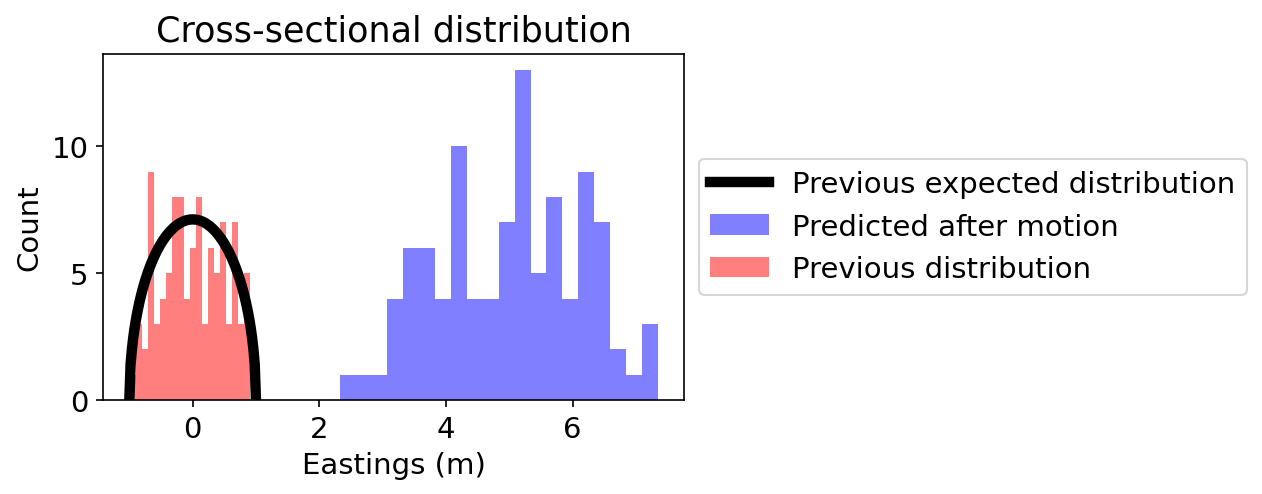

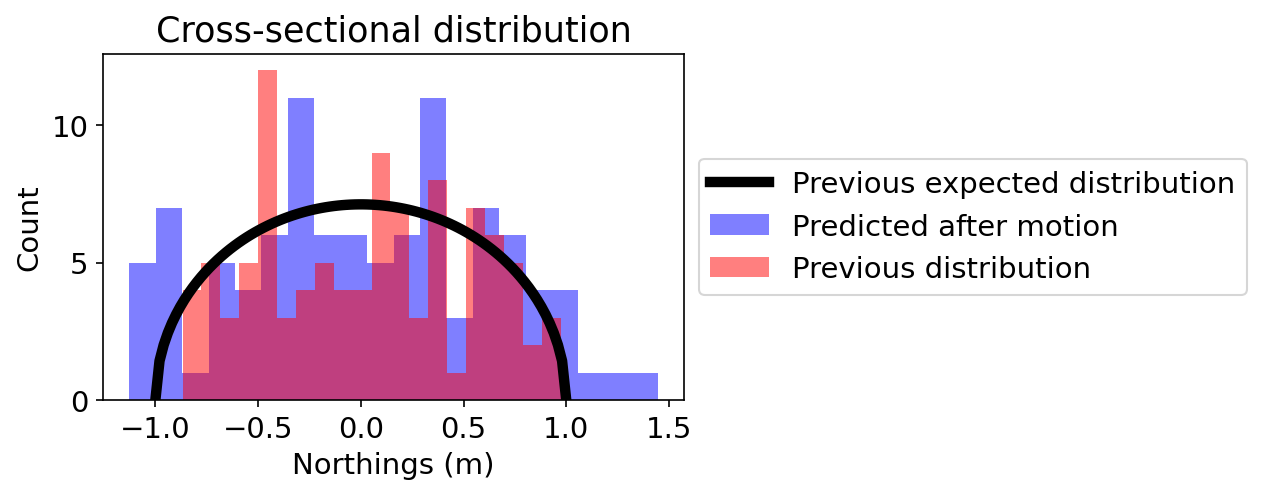

particles.x_dot mean: [0.50310226] m/s std: [0.10543032] m/s


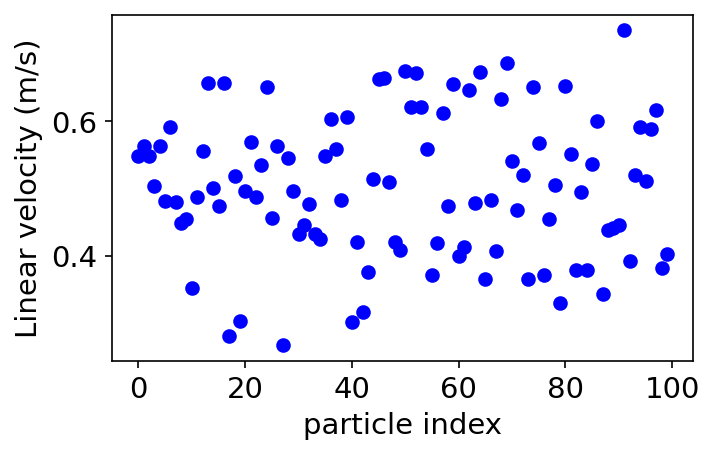

particles.gamma mean: 0.02550712068668634 deg std: 9.761736832768667 deg


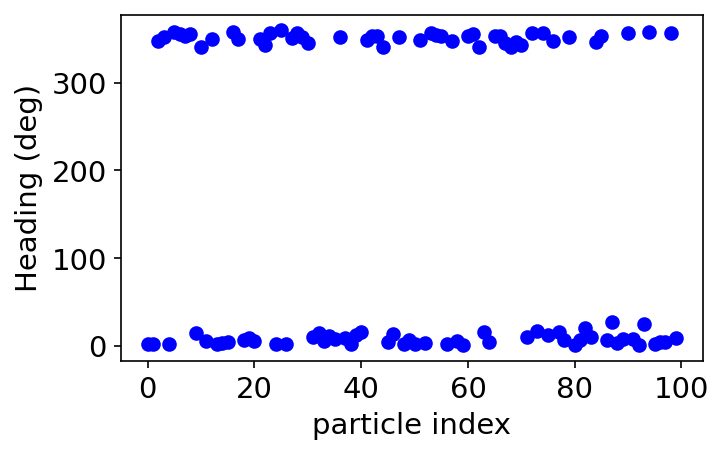

particles.gamma_dot mean: [0.00430456] deg/s std: [0.96335592] deg/s


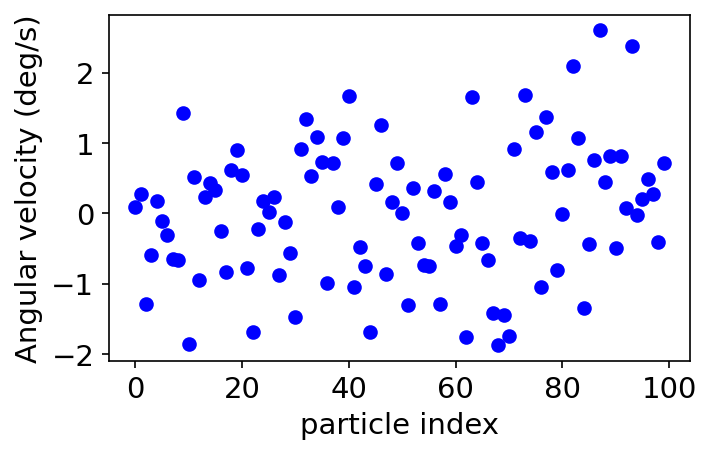

In [16]:
# initialise the particles
N=100; centre = [0,0]; radius = 1
particles = Particles(N)
initialise_particle_distribution(particles, centre, radius)

# expected distribution
x = np.linspace(centre[1]-radius,centre[1]+radius,100)
Nb = (N/np.sqrt(nbins))*np.sqrt(radius**2 - x**2)/(np.pi*radius**2)

# copy so we can compare before and after motion
prev_particles = copy.deepcopy(particles)
#######################################
# set some noise parameters
#######################################
g_std = np.deg2rad(1) #rad
x_dot_std = 0.1 #m/s
g_dot_std = np.deg2rad(1) #rad/s

#######################################
# set control and heading
#######################################
u=Vector(2)
u[0] = 0.5 # m/s
u[1] = np.deg2rad(0) # rad/s
dt = 10

gamma = np.deg2rad(0) #rad

#######################################
# use the motion model
#######################################
discrete_motion_model(particles, gamma, u, dt, [g_std**2, x_dot_std**2, g_dot_std**2]) #variance to make comparable to EKF inputs

#######################################
# plot particles after motion prediction
#######################################
plt.plot(prev_particles.eastings, prev_particles.northings, 'ro', label = 'Previous')
plt.plot(particles.eastings, particles.northings, 'bo', label = 'Predicted after motion')
plt.xlabel("Eastings (m)"); plt.ylabel("Northings (m)"); plt.axis('equal')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)); plt.show()

plt.figure(); 
plt.plot(x, Nb, color = "black", linewidth = 5, label="Previous expected distribution")
plt.hist(particles.northings, alpha=.5, color = "blue", label="Predicted after motion", bins=nbins)
plt.hist(prev_particles.northings, alpha=.5, color = "red", label="Previous distribution", bins=nbins)
plt.title("Cross-sectional distribution"); plt.xlabel("Eastings (m)"); plt.ylabel("Count"); plt.legend()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)); plt.show()


plt.figure(); 
plt.plot(x, Nb, color = "black", linewidth = 5, label="Previous expected distribution")
plt.hist(particles.eastings, alpha=.5, color = "blue", label="Predicted after motion", bins=nbins)
plt.hist(prev_particles.eastings, alpha=.5, color = "red", label="Previous distribution", bins=nbins)
plt.title("Cross-sectional distribution"); plt.xlabel("Northings (m)"); plt.ylabel("Count"); plt.legend()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)); plt.show()


# plot each state to see how they have sampled noise
plt.plot(particles.x_dot, 'bo'); 
print('particles.x_dot mean:', np.mean(particles.x_dot), 'm/s std:', np.std(particles.x_dot), 'm/s')
plt.xlabel("particle index"); plt.ylabel("Linear velocity (m/s)"); plt.show()

# plot each state to see how they have sampled noise
plt.plot(particles.gamma * 180/np.pi, 'bo');                 
print('particles.gamma mean:', wrapped_mean(particles.gamma.tolist()) * 180/np.pi , 'deg std:', wrapped_std(particles.gamma.tolist()) * 180/np.pi, 'deg')
plt.xlabel("particle index"); plt.ylabel("Heading (deg)"); plt.show()

plt.plot(particles.gamma_dot * 180/np.pi, 'bo'); 
print('particles.gamma_dot mean:', np.mean(particles.gamma_dot) * 180/np.pi, 'deg/s std:', np.std(particles.gamma_dot) * 180/np.pi, 'deg/s')
plt.xlabel("particle index"); plt.ylabel("Angular velocity (deg/s)"); plt.show()

Check the model for a set of controls
> v = 2 m/s, w=0 deg/s, gamma = 0 deg for 10s
>
> v = 2 m/s, w=0 deg/s, gamma = 90 deg for 10s
>
> v = 0 m/s, w=9 deg/s, gamma = 0 deg for 10s
>
> v = 2 m/s, w=9 deg/s, gamma = 0 deg for 10s

C:\Users\skyem\AppData\Local\Temp\ipykernel_6264\4218822168.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  particles.northings[i] = p[0]
C:\Users\skyem\AppData\Local\Temp\ipykernel_6264\4218822168.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  particles.eastings[i] = p[1]
C:\Users\skyem\AppData\Local\Temp\ipykernel_6264\4218822168.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  particles.gamma[i] = p[2]


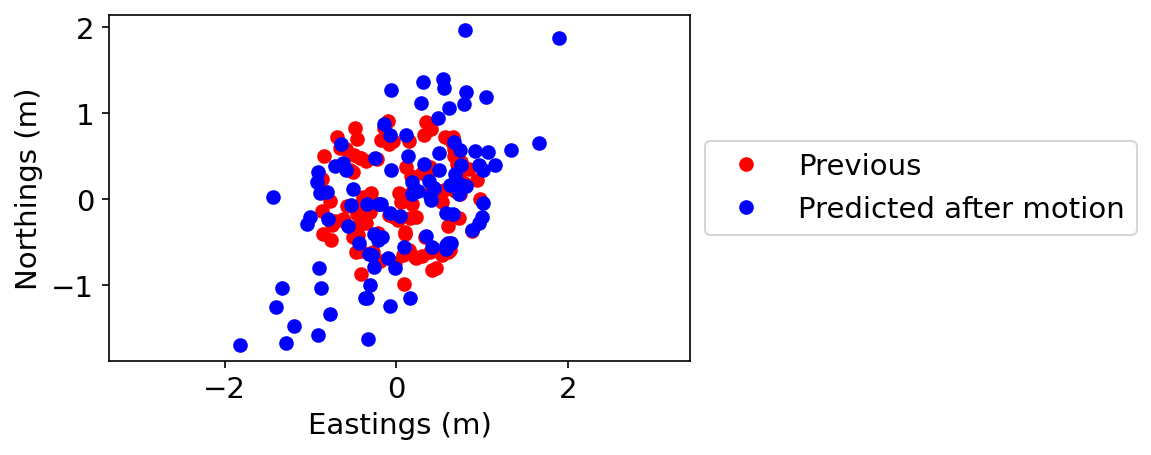

In [ ]:
#######################################
# initialise the particles
#######################################
N=100; centre = [0,0]; radius = 1
particles = Particles(N)
initialise_particle_distribution(particles, centre, radius)

#######################################
# set some noise parameters
#######################################
g_std = np.deg2rad(1) #rad
x_dot_std = 0.1 #m/s
g_dot_std = np.deg2rad(1) #rad/s

#######################################
# set control and heading
#######################################
u=Vector(2)
u[0] = 0 # m/s
u[1] = np.deg2rad(9) # rad/s
dt = 10

gamma = np.deg2rad(9) #rad

#######################################
# use the motion model
#######################################
discrete_motion_model(particles, gamma, u, dt, [g_std**2, x_dot_std**2, g_dot_std**2])

#######################################
# plot particles after motion prediction
#######################################
plt.plot(prev_particles.eastings, prev_particles.northings, 'ro', label = 'Previous')
plt.plot(particles.eastings, particles.northings, 'bo', label = 'Predicted after motion')
plt.xlabel("Eastings (m)"); plt.ylabel("Northings (m)"); plt.axis('equal')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)); plt.show()


## <span style="color:green">3. Measurement update: Update weights</span>
Particle weights $w^{[n]}_k$ are updated based on a sensor measurements that act equally on all particles:

$$\mathbf{z}_{k} = h(\overline{\mathbf{x}}_{k}) + n_k$$

Our Rao-Blackwellised PF updates particles using position measurements because:  
- Fewer particles are needed to describe the state.  
- Other uncertainties manifest as position errors.  
- Position shows the most non-linearity (e.g., multi-state hypothesis when using map references).  

We compare measured positions to those predicted by each particle's state hypothesis $\mathbf{\overline{z}}_k$. We assume GPS-like external measurements but can adapt the method for range measurements to map features (e.g., lidar on a horizontal plane or terrain elevation mapping on a vertical plane).

The cell below creates a measurement class and sets its parameters as 
> N=0.5, E=0.5m with respective standard deviations of 0.5m

And also generates a set of particles around:
>N,E = 0,0 m
>with a distribution radius of 1m

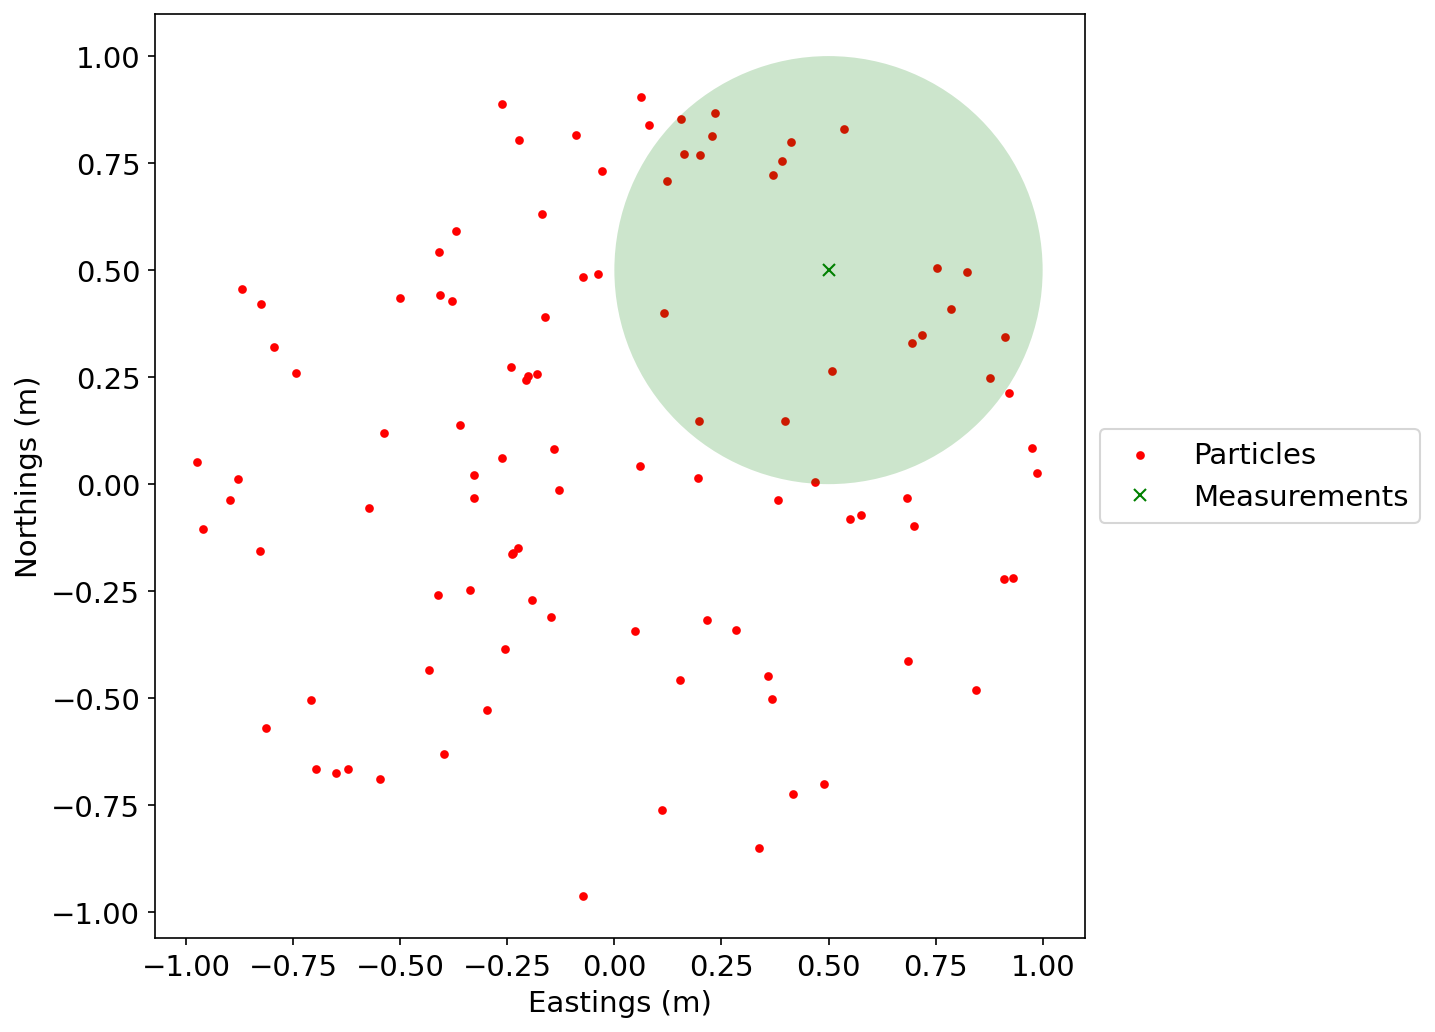

In [19]:
from sklearn.neighbors import KernelDensity  
from plot_feeg6043 import plot_pf_trajectory
from matplotlib.patches import Ellipse

class Measurement:
    def __init__(self):
        self.timestamp = np.array([None])
        self.northings = np.array([None])
        self.eastings = np.array([None])
        self.northings_std = np.array([None])
        self.eastings_std = np.array([None])   
                
def plot_pf_trajectory(timestamps, particle_list, particles_kde = None, particles_std = None, particles_neff = None, measurement_list=None, show_weights = False):

    plt.figure(figsize=[8, 8])

    for p in particle_list:
        if show_weights == True: sizes = p.weight*p.N*10
        else: sizes = 10
        plt.scatter(p.eastings, p.northings, c='red', s=sizes, label='Particles')

    ax = plt.gca()
                
    if particles_kde is not None:
        plt.plot(particles_kde[:,1],particles_kde[:,0],'bo', label='KDE state estimate')
        
    if measurement_list is not None:
        for m in measurement_list:
            e = Ellipse(xy=(m.eastings, m.northings), width=2*m.eastings_std, height=2*m.northings_std, angle=0)
            e.set_alpha(0.2)
            e.set_facecolor("green")
            ax.add_patch(e)
            plt.plot(m.eastings, m.northings, "gx", label='Measurements')            

            
    plt.xlabel("Eastings (m)",fontsize=14); plt.ylabel("Northings (m)",fontsize=14)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)); plt.axis('equal'); plt.show()
    
    if particles_std is not None:
        plt.plot(timestamps, particles_std[:,0],'ro', label='Northings')
        plt.plot(timestamps, particles_std[:,1],'bo', label='Eastings')        
        plt.xlabel("Time, s)",fontsize=14); plt.ylabel("Standard deviation, m",fontsize=14)    
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)); plt.show()

    if particles_neff is not None:
        plt.plot(timestamps, particles_neff[:,0],'ko', label='Northings')
        plt.xlabel("Time, s)",fontsize=14); plt.ylabel("Proportion of effective particles",fontsize=14)  
        plt.ylim([0,1.1])
        plt.show()



# Create measurements
measurement = Measurement()
measurement.northings = 0.5
measurement.eastings = 0.5
measurement.northings_std = 0.5
measurement.eastings_std = 0.5

# Create and initialise our particles
particles = Particles(100)
initialise_particle_distribution(particles, centre = [0,0], radius = 1)

# Plot particles and measurements
plot_pf_trajectory([0], [particles], measurement_list = [measurement])

The particle weights are updated as follows:

$$w^{[n]}_k=p(\mathbf{z}_k|\overline{\mathbf{x}}^{[n]}_k)\cdot w^{[n]}_{k-1}$$

We compute the measurement probability distribution $\tau(\cdot)$ to prior distribution $\bar\tau(\cdot)$ ratio to update each particle's weight:

\begin{equation} 
\color{red}{w^{[n]}_k}=\dfrac{\color{blue}{\tau(x^{[n]}_k)}}{\color{green}{\bar\tau(x^{[n]}_k)}}{\color{green}{w^{[n]}_{k-1}}} \hspace{0.5cm}, \textrm{where} \hspace{1cm} \sum^N_{n=1}w^{[n]}_k=1
\end{equation} 

where $\tau(\cdot)$ and $\bar\tau(\cdot)$ can have any distribution. The prior probability can be computed from the density of particles using Kernel Density Estimation (KDE), which uses a moving window to determine the continuous density distribution at a given target resolution defined by $\sigma_{res}$ (width of Kernel). For each particle ($N_k, E_k$) we compute: 

$$ \bar\tau(N_k, E_k) = p_{KDE}(N_k, E_k)=\dfrac{1}{N}\sum^N_{n=1}\dfrac{1}{\sqrt{2\pi\sigma^2_{res}}}\exp\left(-\dfrac{(N_k-N_n)^2+(E_k-E_n)^2}{2\sigma^2_{res}}\right)$$

where $\sum^N_{n=1}$ term computes probability based on the distribution of all particles. 

<div class="alert alert-block alert-info">
    <b>KDE density:</b> The resolution to compute density over is a choice. A reasonable way to think about this is that the resolution shouldn't be smaller than our measurement uncertainty, as the measurement would become the bottleneck. At the same time, if it is too low, then the particles would all have the same level of importance, which could lead to particle depletion as likely locations wouldn't be prioritised. Setting the resolution to match the sensor uncertainty ensures that particles in low density areas are considered important.<br>
</div>

For the observation $\tau(\cdot)$, we can assume a sensor with a Gaussian distribution (e.g., GPS) that measures position $N_z, E_z$ with a measurement uncertainty of $\delta$ for basic position estimation, where for each particle with position $N_k, E_k$ we get its measurement likelihood as:

$$ \tau(N_k, E_k) = \dfrac{1}{\sqrt{2\pi\delta^2}}\exp\left(-\dfrac{(N_k-N_z)^2+(E_k-E_z)^2}{2\delta^2}\right)$$

though this can be changed to any distribution. The likelihood functions and particle updates are implemented below.

In [ ]:
def pf_measurement_probability(particles, measurement):    
    # calculate likelihood of each particle given the observation 
    delta = np.sqrt(measurement.northings_std*measurement.eastings_std)
    probability = []
    for i in range(particles.N):
        particle_to_measurement= (particles.northings[i] - measurement.northings) ** 2 + (particles.eastings[i] - measurement.eastings) ** 2 
        num = np.exp(-(particle_to_measurement)/(2*delta**2))
        den = np.sqrt(2*np.pi*delta**2)
        probability.append(num/den)   
        
    return probability

from sklearn.neighbors import KernelDensity  

def pf_kde_probability(particles, sigma_resolution=1.0, sampling_resolution=None):
    
    # fit the particles to the KDE model
    locations = np.vstack([particles.northings, particles.eastings])
    
    if sampling_resolution == None:
        # returns the probability of each particle location
        kde = KernelDensity(kernel='gaussian', bandwidth=sigma_resolution).fit(locations.T)
        log_density = kde.score_samples(locations.T)
        probability = np.exp(log_density)
        
        return probability   
    
    else:
        # returns the most likely location at a given sample resolution
        kde = KernelDensity(kernel='gaussian', bandwidth=sigma_resolution).fit(locations.T, sample_weight=particles.weight.T)

        state_range_northings = np.linspace(min(particles.northings),max(particles.northings), num=sampling_resolution)
        state_range_eastings = np.linspace(min(particles.eastings),max(particles.eastings), num=sampling_resolution)

        state_range = np.vstack([state_range_northings, state_range_eastings])
        density = kde.score_samples(state_range.T)       
        est_northings, est_eastings = state_range.T[density.argmax()]
        
        return est_northings, est_eastings    

def pf_normalise_weights(weights):
    ws = sum(weights)
    for i in range(len(weights)):
        weights[i] /= ws    
    return weights

def pf_update(particles, measurements):
    tau = pf_measurement_probability(particles,measurements)
    
    sigma_resolution = np.sqrt(measurement.northings_std*measurement.eastings_std)
    prior_tau = pf_kde_probability(particles, sigma_resolution)

    particles.weight *= tau/prior_tau
    pf_normalise_weights(particles.weight)

    return particles

# initialise some particles
particles = Particles(100)
initialise_particle_distribution(particles, centre = [0,0], radius = 1)

Run these functions and check what is happening with the particle weights. 

<div class="alert alert-block alert-info">
<b>Task:</b> Run the cell below 10 times. <br>
    - What do you notice about the particle weights and distribution?<br>
    - Can you explain it?<br>
</div>





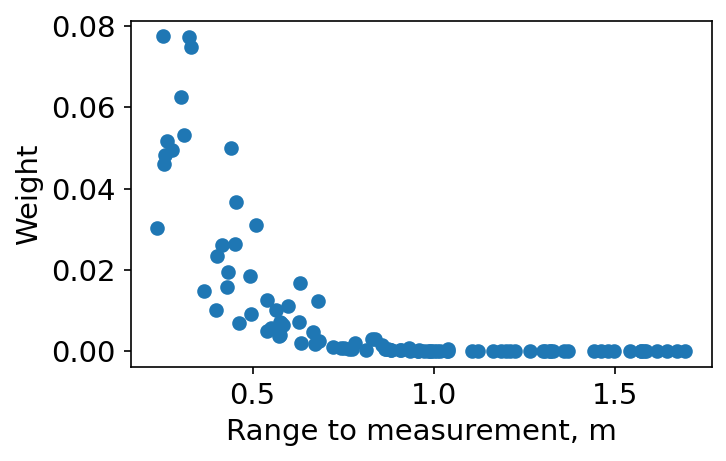

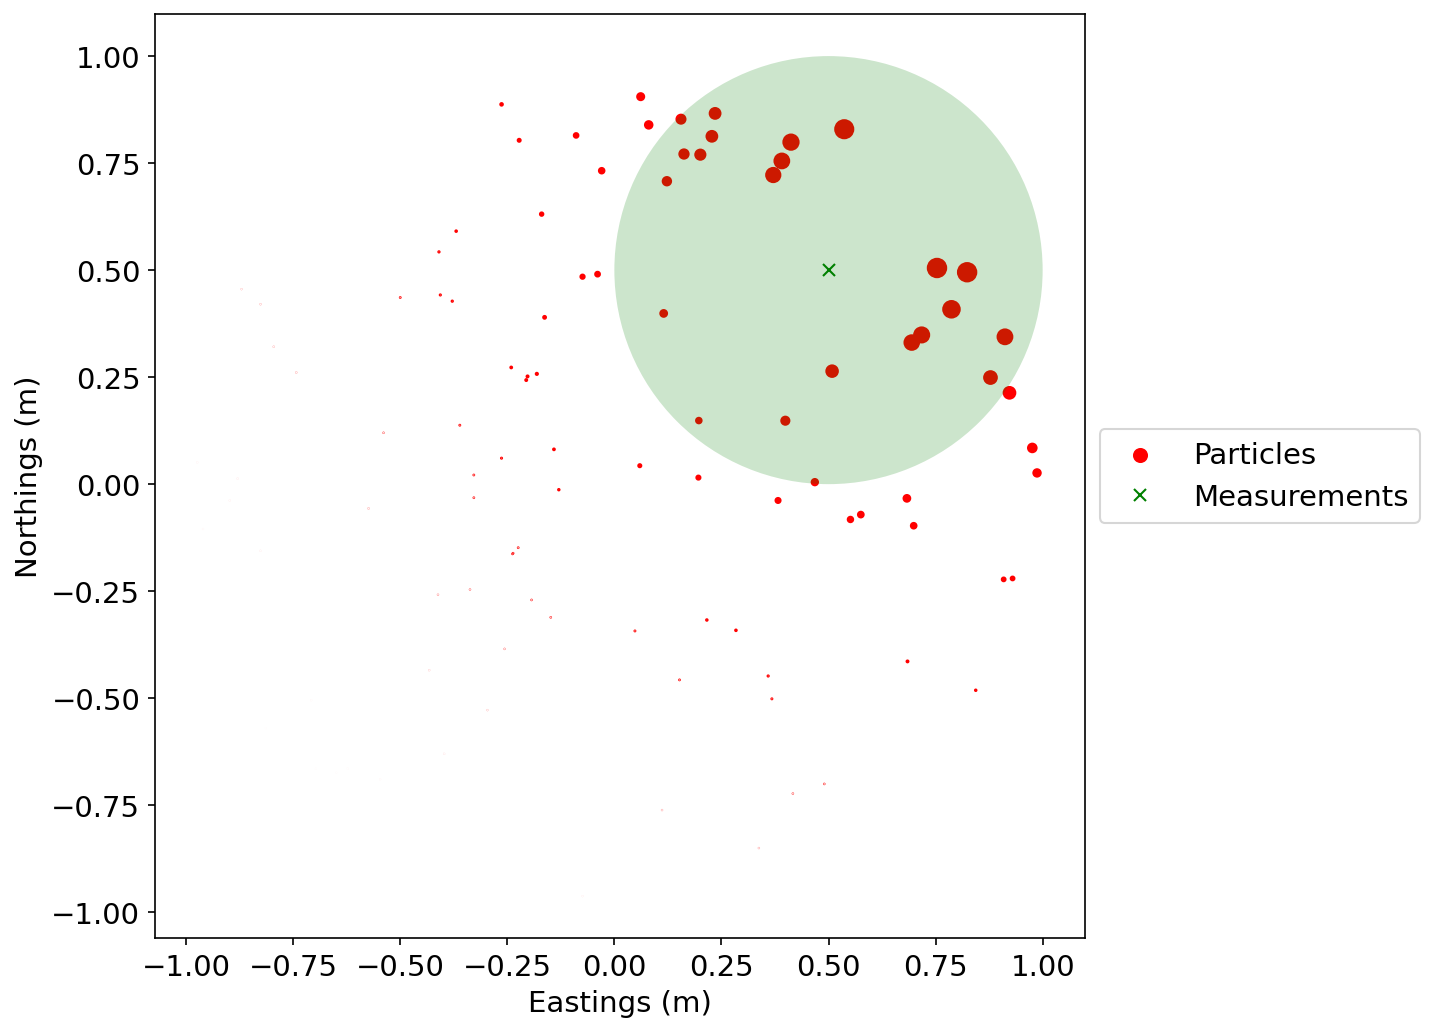

In [22]:
# Create and initialise our particles

pf_update(particles, measurement)

ranges = np.sqrt((particles.northings-measurement.northings)**2+(particles.eastings-measurement.eastings)**2)
plt.plot(ranges, particles.weight,'o')
plt.ylabel('Weight'); plt.xlabel('Range to measurement, m'); plt.show()

# Plot particles and measurements
plot_pf_trajectory([0], [particles], measurement_list = [measurement], show_weights = True)     

## <span style="color:green"> Update States: Resampling</span>

Updating particle weights indicates their likelihood but does not alter our state estimate. Weights are updated only where particles exist, so it's crucial to have particles in regions of high measurement likelihood. 

Resampling transfers information from particle weights to states, increasing the particle count in high-weight areas and removing them from low-weight areas. Using the probability ratio (i.e., $\tau/\pi$) allows particles in low-density regions to receive higher weighting for the same measurement probability so achieve a more even distribution in high-likelihood areas.

**When to resample:** Since sensor measurements contain noise, resampling after every measurement risks depleting particles from likely areas making them unable to recover (weights, likelihoods etc can only be computed where particles exist). 

Triggering resampling based on how effective current particles are addresses this. Since weights are normalised, the the proportion of effective particles can be determined from the variance of particle weights:

$$\eta_{eff} = \frac{1}{N}\cdot\frac{1}{\sum _{n=1}^{N}\left(w_{k}^{[n]}\right)^{2}}$$

We need a threshold below which to judge the current particles as inefficiently distributed and in need of resampling. A common threshold is 50\%, where increasing this will resample more often, and decreasing will resample less often

In [24]:
def neff(particles): 
    particles.weight /= np.sum(particles.weight)
    return 1.0 / (particles.N * np.sum(np.square(particles.weight)))

particles = Particles(4)

particles.weight = np.array([.1, .1, .1, .7])
print('***********************************************')
print('For particles with weights:', particles.weight)
print('The proportion of effective particles is:', neff(particles))

# try a different set of weights
particles.weight = np.array([0.25, 0.25, 0.25, 0.25])
print('***********************************************')
print('For particles with weights:', particles.weight)
print('The proportion of effective particles is:', neff(particles))

# # try a set of weights that won't require resampling
# particles.weight = np.array([?, ?, ?, ?])
# print('***********************************************')
# print('For particles with weights:', particles.weight)
# print('The proportion of effective particles is:', neff(particles))

***********************************************
For particles with weights: [0.1 0.1 0.1 0.7]
The proportion of effective particles is: 0.48076923076923084
***********************************************
For particles with weights: [0.25 0.25 0.25 0.25]
The proportion of effective particles is: 1.0


**How to resample:** Particles can be systematically resampled in proportion to their weights by stacking the particle weights and then sampling particles at equal weight intervals ($1/N$). 

Adding a random number $r$ between 0 and $1/N$ offsets the sampling phase and so randomises particle selection near stacked weight boundaries:
$$ i = \underset{j}{\operatorname{argmin}} \sum^j_{m=1}w^{[n]}_t \geq r+\dfrac{(n-1)}{N}$$

First we represent the weights of all particles as a cummulative sum and implement systematic resampling. 
- Check how many times each particle gets sampled
- Try running the cell a few times to see how different particles get chosen

Indexes: [0, 1, 2, 3]
Weights: [np.float64(0.1), np.float64(0.1), np.float64(0.1), np.float64(0.7)]
Indexes to resample: [2 3 3 3]


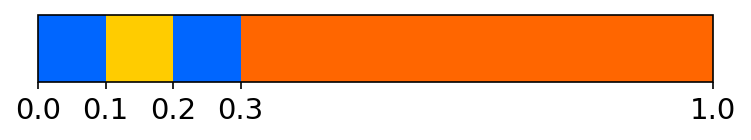

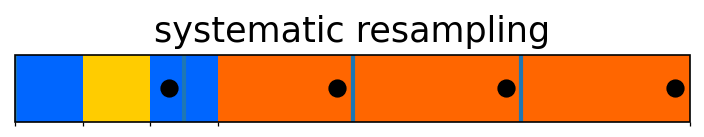

In [25]:
## initialise particles
particles = Particles(4)
initialise_particle_distribution(particles)
particles.weight = [.1, .1, .1, .7]

## Stacked weights
plot_cumsum(particles.weight)
indexes, random_number = systematic_resample(particles.weight, demo=True)
plot_systematic_resample(particles.weight, random_number)

print("Indexes:", list(range(particles.N)))
print("Weights:", particles.weight)
print("Indexes to resample:", indexes)

Once particles to resample have been determined, we add small random offsets ("innovations") to the particles generated from them. This avoids having particles being exact duplicates, where some proportion can end up in more likely regions than the original distribution. 

<div class="alert alert-block alert-info">
    <b>How much jitter?</b> We need to use engineering judgment to determine an appropriate amount of jitter. A sensible approach is to relate it to our measurement uncertainty. If the jitter is much smaller than the measurement uncertainty, the sensor won't distinguish between child particles. Conversely, if the jitter is much larger, the child particle distribution may move away from high-probability areas. Setting the jitter to match sensor uncertainty ensures that new particles receive different future weight updates while remaining densely populated in regions of high measurement probability.<br>
</div>

When particles are resampled, the weights are reset to be equal across all particles as likelihood information has been trasnsfered to their positions.

In [26]:
def pf_resample(particles, jitter, verbose = False):
    """Resample particles using systematic resample"""
    
    if verbose == True: print('effective particles:', neff(particles))
    if neff(particles) < 0.8:
        # Get the indexes of the particles to resample
        indexes = systematic_resample(particles.weight)
        if verbose == True: print('Resampling needed, sampled particles:',indexes)
              
        # Copy all the particles, to overwrite "particles"
        particles_copy = copy.deepcopy(particles)
        
        angle = np.random.uniform(0,2*np.pi, particles.N)
        radius = np.random.normal(0,jitter, particles.N) 
        
        northings, eastings = polar2cartesian(radius,angle)
        
        # Overwrite "particles" with the copied ones and correct indices
        for i in range(particles.N):
            particles.northings[i] = copy.deepcopy(particles_copy.northings[indexes[i]])+northings[i]
            particles.eastings[i] = copy.deepcopy(particles_copy.eastings[indexes[i]])+eastings[i]
        
        # Reset the weights to equally probable
        particles.weight = np.ones(particles.N) / float(particles.N)
    else: 
        if verbose == True: print('No resampling needed')


Check with the code below that the resampling is doing what is expected.
- First try with $N=4$ and $\mathbf{w}=[0.2, 0.1, 0.2, 0.5]$
- First try with $N=4$ and $\mathbf{w}=[0.1, 0.1, 0.1, 0.7]$

In [33]:
particles = Particles(4)
initialise_particle_distribution(particles)
particles.weight = np.array([0.1, 0.1, 0.1, 0.7])

print("BEFORE")
print("------")
print(particles)
print("------")
pf_resample(particles, np.sqrt(measurement.northings_std*measurement.eastings_std), verbose=True)
print("------")
print("AFTER")
print(particles)

BEFORE
------
northings: [-0.94495522 -0.40607656 -0.38808412 -0.13742529]
eastings: [-0.32532235 -0.01399605  0.37507956  0.69166073]
weights: [0.1 0.1 0.1 0.7]
------
effective particles: 0.48076923076923084
Resampling needed, sampled particles: [0 2 3 3]
------
AFTER
northings: [-0.24019958 -0.58563458  0.24988214 -0.30471579]
eastings: [-0.24659154  0.55539025  1.31403145  0.67535889]
weights: [0.25 0.25 0.25 0.25]


<div class="alert alert-block alert-info">
    <b>Check:</b> Did the particles resample correctly?
</div>

## 4. Extract states

The updated particle distribution represents the belief, but robots need the determine their most likely estimates to decide the next course of action. Taking a mean of the distribution encounter the same issue as EKFs for multistate hypotheses and can fall into a region that is known to be unlikely (often avoiding this motivates PF use to start with). 

KDE can identify the highest density of particles, which represents the most likely state, just as in computing particle prior probability $\bar\tau$ to update particle weights.

In [36]:
particles = Particles(3) 
initialise_particle_distribution(particles)
sigma_resolution = np.sqrt(measurement.northings_std*measurement.eastings_std)
sampling_resolution = 100 #samples over northings and easting range respectively

print('---')

particles.weight = np.array([0.1, 0.1, 0.8])
print(particles)
print('Most likely state', kde_probability(particles, sigma_resolution, sampling_resolution))
print('Mean northings, eastings', np.mean(particles.northings),np.mean(particles.eastings))

print('---')

# # try a different set of weights
# particles.weight = np.array([??, ??])
# print(particles)
# print('Most likely state', kde_probability(particles, sigma_resolution, sampling_resolution))

---
northings: [-0.28760686 -0.06108174 -0.15671801]
eastings: [-0.84515814  0.08719629  0.22715718]
weights: [0.1 0.1 0.8]
Most likely state (np.float64(-0.07023426875815558), np.float64(0.18383130971655426))
Mean northings, eastings -0.16846886656815366 -0.1769348911250311
---


<div class="alert alert-block alert-info">
    <b>Check:</b> Is the most likely state correct?
</div>

## 2D Robot Motion: Put the pieces together

Use all the code above to create a PF using the measurements provided in the cells below. The example follows the same control and measurement scenario as the EKF tutorial

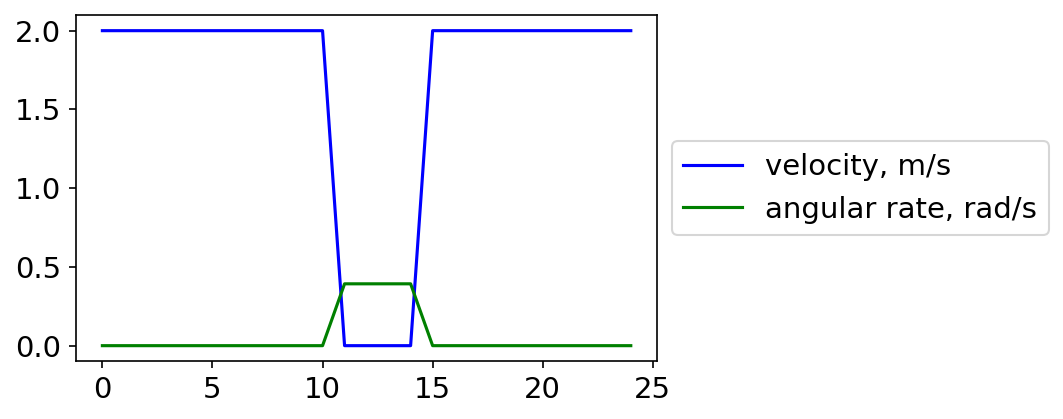

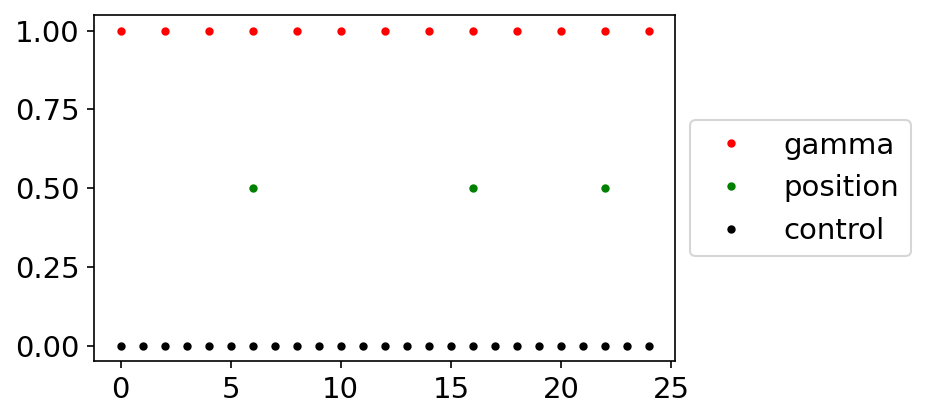

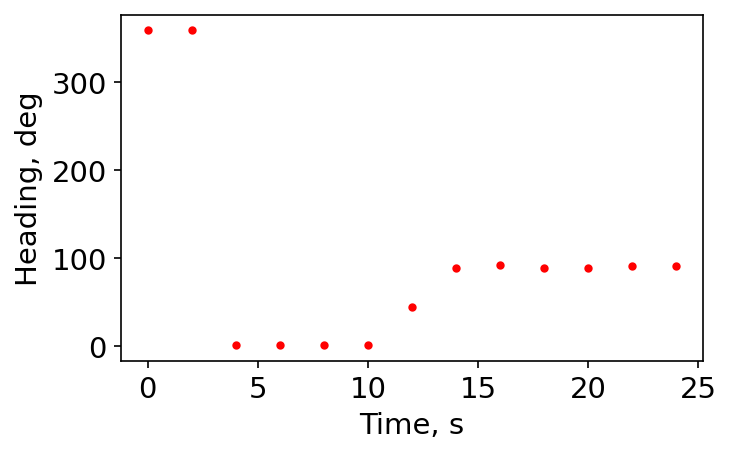

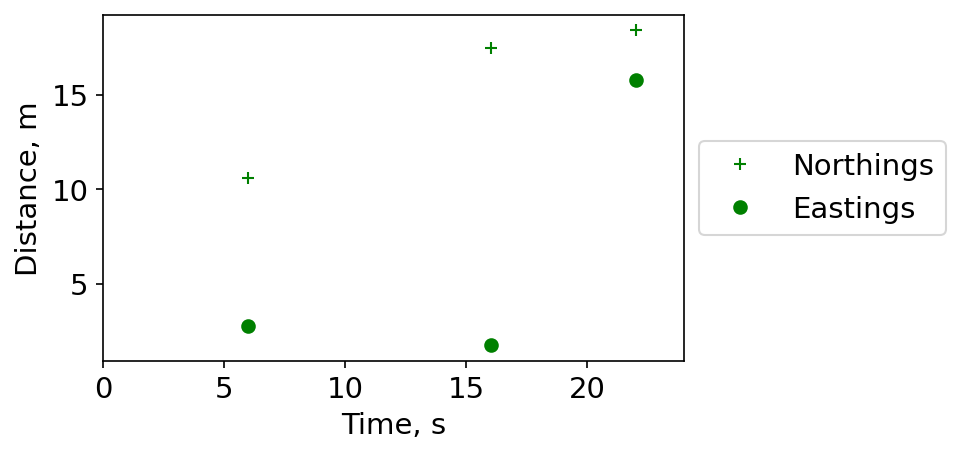

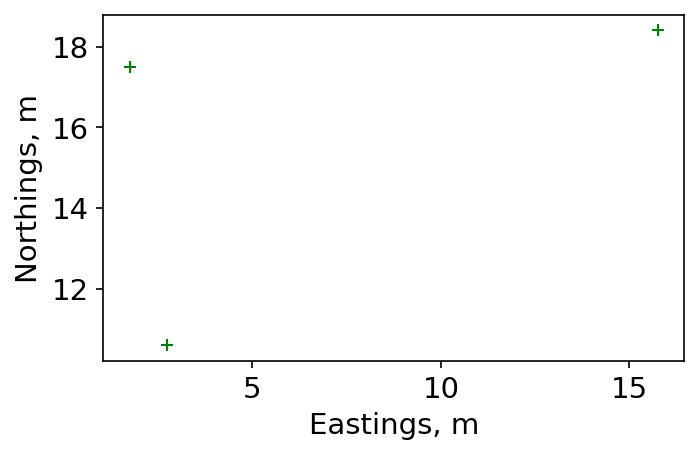

In [37]:
start = 0
end = 24
timestep = 1 #s
num_points = int( end / timestep )+1
t_list = np.linspace(start, end, num_points)
v_list = []
w_list = []
for i in range(len(t_list)):
    if t_list[i] <= 10:
        v_list.append(2)
        w_list.append(np.deg2rad(0.0))
    elif t_list[i] <= 14:
        v_list.append(0)
        w_list.append(np.deg2rad(90/4))
    else:
        v_list.append(2)
        w_list.append(np.deg2rad(0.0))   
    
T_u = l2m(t_list)
U = l2m([v_list,w_list])

plt.plot(T_u,U[:,0],'b-',label = 'velocity, m/s')
plt.plot(T_u,U[:,1],'g-',label = 'angular rate, rad/s')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)); plt.show()

# create some fake heading sensor readings
t_g_list = [0,2,4,6,8,10,12,14,16,18,20,22,24]
g_list = np.deg2rad([0,0,0,0,0,0,45,90,90,90,90,90,90]).tolist()
g_std = [np.deg2rad(1)] * len(g_list)

# create some fake position sensor readings
t_ne_list = [6,16,22]
n_list = [12,20,20]
e_list = [0,4,16]
n_std = [1] * len(n_list)
e_std = [1] * len(e_list)


# add noise to make things more realistic
for i in range(len(t_g_list)): 
    g_list[i]=(g_list[i]+np.random.normal(0, g_std[i])) % (2*np.pi)

    
measurement = Measurement()    
measurement_list = []
for i in range(len(t_ne_list)): 
    n_list[i]=n_list[i]+np.random.normal(0, n_std[i])
    e_list[i]=e_list[i]+np.random.normal(0, e_std[i])    
    
    # pack into our measurement class
    measurement.timestamp = t_ne_list[i]
    measurement.northings = n_list[i]
    measurement.eastings = e_list[i]
    measurement.northings_std = n_std[i]
    measurement.eastings_std = e_std[i]    
    measurement_list.append(copy.deepcopy(measurement))

    
#create our matrices
Z_ne = l2m([n_list,e_list])
T_ne = l2m(t_ne_list)
Z_g = l2m([g_list])
T_g = l2m(t_g_list)
G_std = l2m(g_std)
NE_std = l2m([n_std,e_std])

plt.plot(T_g,np.ones([len(T_g),1]),'r.',label='gamma')
plt.plot(T_ne,0.5*np.ones([len(T_ne),1]),'g.',label='position')
plt.plot(T_u,0.*np.ones([len(U),1]),'k.',label='control')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)); plt.show()

plt.plot(T_g,np.rad2deg(Z_g),'r.')
plt.xlabel('Time, s')
plt.ylabel('Heading, deg')
plt.show()

plt.plot(T_ne,Z_ne[:,0],'g+',label = 'Northings')
plt.plot(T_ne,Z_ne[:,1],'go',label = 'Eastings')
plt.xlabel('Time, s')
plt.ylabel('Distance, m')
plt.xlim([min(t_g_list),max(t_g_list)])
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)); plt.show()

plt.plot(Z_ne[:,1],Z_ne[:,0],'g+')
plt.xlabel('Eastings, m')
plt.ylabel('Northings, m')
plt.show()

Handling angles with Rao-Blackwellisation needs some care. First, when there is no sensor update we just use our motion model to progress angle estimates. Our reference angle becomes the mean angle, but we need to handle angle wrapping. This can be done using the circular mean:

$$\bar{\theta} = \text{atan2} \left( \sum_{i=1}^{N} \sin(\theta_i), \sum_{i=1}^{N} \cos(\theta_i) \right)$$

If we have 
angles = [0, 359]

In [ ]:
def wrapped_mean(angles): return np.arctan2(np.sum(np.sin(angles)), np.sum(np.cos(angles)))    

angles = np.deg2rad([0, 359]).tolist()
print('Arithmetic mean of:',np.rad2deg(angles).tolist(),'deg is:', np.rad2deg(np.mean(angles)),'deg')
print('Wrapped mean of:',np.rad2deg(angles).tolist(),'deg is:', np.rad2deg(wrapped_mean(angles)),'deg')

When a sensor reading is available, the Rao-Blackwellisation means that it is **not** treated as a measurement for PF update, but used to overwrite the mean particle angle prediction. When there is no heading measurement, then the particles use their stored angles and add noise for use in the motion model. 

<div class="alert alert-block alert-info">
    <b>Task 1:</b> Run the prediction only version (just monitor neffective particles but done update). <br>
    <b>Task 2:</b> What happens when you increase the motion noise (linear and angular velocity noise )? <br>     
    <b>Task 3:</b> Add heading measurements as part of the Rao-Blackwellisation, how have things changed? <br>
    <b>Task 4:</b> Add NE position measurements as part of the PF, how have things changed? <br>    
    <b>Task 5:</b> What happens when you increase/decrease the number of particles? <br>
</div>

C:\Users\skyem\AppData\Local\Temp\ipykernel_6264\4218822168.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  particles.northings[i] = p[0]
C:\Users\skyem\AppData\Local\Temp\ipykernel_6264\4218822168.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  particles.eastings[i] = p[1]
C:\Users\skyem\AppData\Local\Temp\ipykernel_6264\4218822168.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  particles.northings[i] = p[0]
C:\Users\skyem\AppData\Local\Temp\ipykern

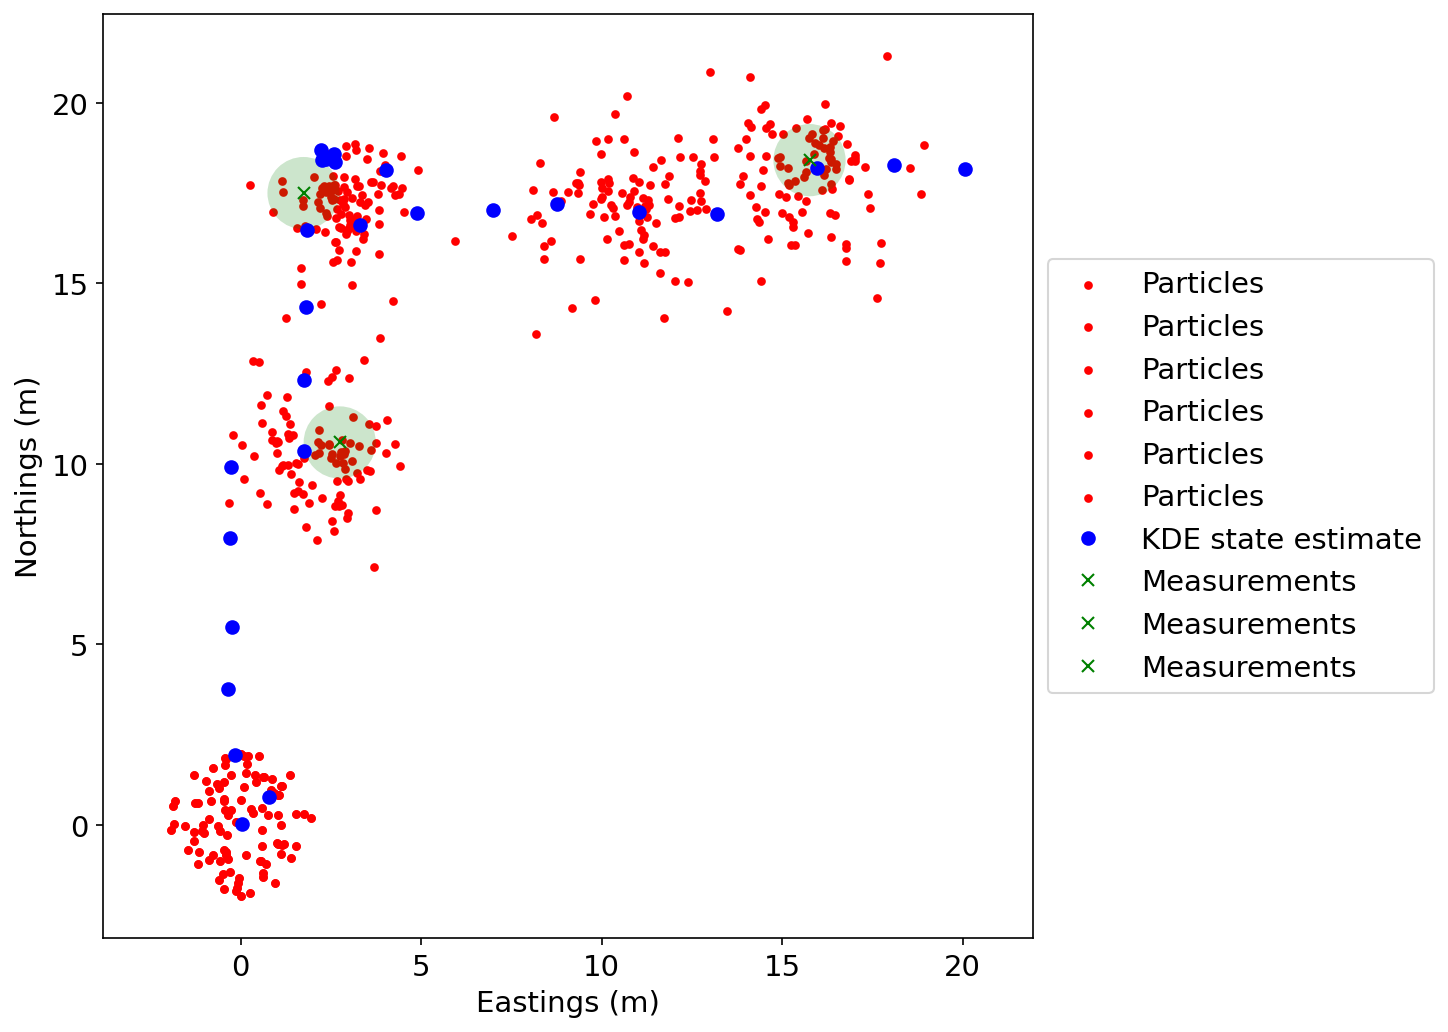

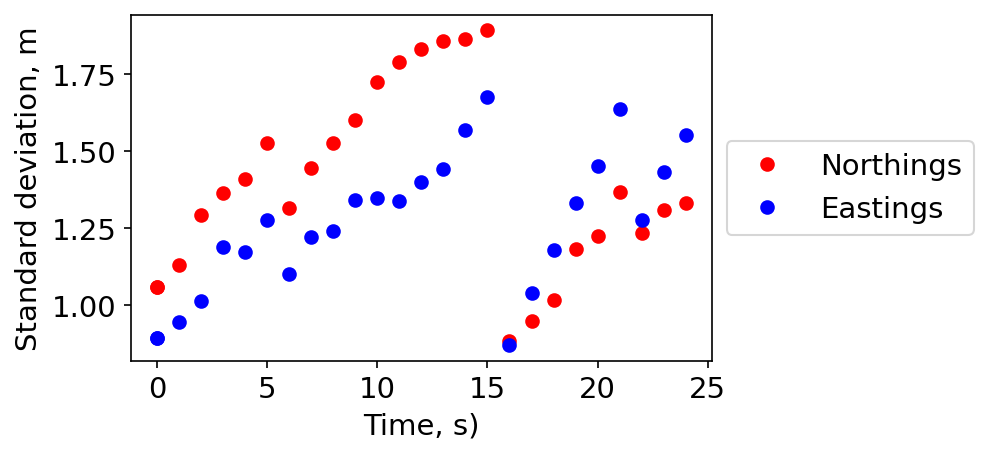

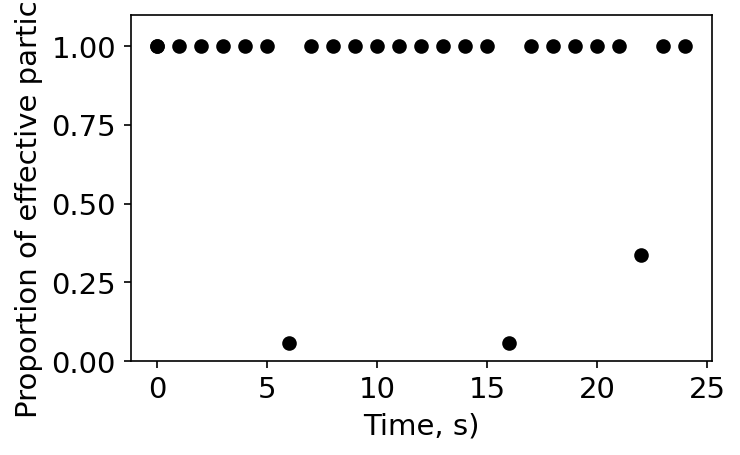

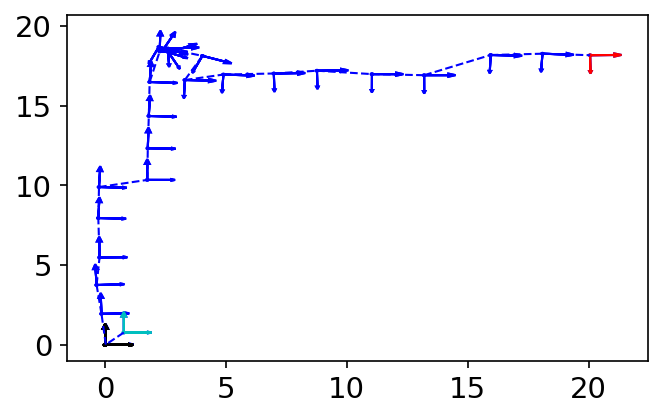

In [ ]:
from plot_feeg6043 import plot_2dframe, plot_path

# Use the following parameters
N             = 100   # Number of particles
northings_std = 1   # m
eastings_std  = 1   # m
g_std   = np.deg2rad(1)   # rad
x_dot_std = 0.3 #m/s
g_dot_std = np.deg2rad(0.1) #rad/s

# Initialise PF 
particles = Particles(N)
initialise_particle_distribution(particles, centre=[-0., 0.], radius = np.sqrt(4*northings_std*eastings_std))
particles.gamma = [0]*particles.N
particle_list = []

# define pointers for our control and measurement data
u_idx = 0
g_idx = 0
ne_idx = 0

# get initial and timestamp and create containor to store times
t_prev=np.min([T_u[0],T_g[0],T_ne[0]])
t_end=np.max([T_u[-1],T_g[-1],T_ne[-1]]) 
T = Vector(1)
T[0,0] = t_prev

# KDE locations
P_KDE = Matrix(1,3) #pose
P_STD = Matrix(1,2) #just northings and eastings as heading isn't part of the update

# set the initial conditions
P_KDE[0,0] = kde_probability(particles, sigma_resolution, sampling_resolution)[0]
P_KDE[0,1] = kde_probability(particles, sigma_resolution, sampling_resolution)[1]
P_KDE[0,2] = wrapped_mean(particles.gamma)
gamma = None

P_neff = Vector(1)
P_neff[0,0] = neff(particles)

particle_x_dot = Vector(1)
particle_gamma_dot = Vector(1)

# initialise containors to store results
P_STD[0,0] = np.std(particles.northings)
P_STD[0,1] = np.std(particles.eastings)
particle_list.append(copy.deepcopy(particles))

sigma_resolution = np.sqrt(measurement.northings_std*measurement.eastings_std)
sampling_resolution = 100 #samples over northings and easting range respectively

# every 10 frames store and show the particles
key_frame = 20
frame = 20
#################################################################
# Main simulation loop
#################################################################
while t_prev < t_end:    
    
    # Check which timestamp to process first
    next_stamp = None
    u_stamp = None
    g_stamp = None
    ne_stamp = None 
          
    if u_idx < len(T_u):
        u_stamp = T_u[u_idx]

    if g_idx < len(T_g):
        g_stamp = T_g[g_idx]

    if ne_idx < len(T_ne):
        ne_stamp = T_ne[ne_idx]        
    
    potential_stamps = [
        u_stamp,
        g_stamp,
        ne_stamp        
    ]
        
    valid_stamps = [i for i in potential_stamps if i is not None]
    
    if valid_stamps:
        t = min(valid_stamps) 
    else:
        break  # If there is no timestep left to predict to, simulation finishes
    
    dt = t - t_prev
    
    if t == u_stamp:
        u = U[u_idx:u_idx+1,:].T  
        u_idx += 1  
            
    if t == g_stamp: 
        gamma = Z_g[g_idx:g_idx+1,:]
        if g_idx < len(T_g): g_idx+=1 
    else:
        gamma = None
        
    # when this is none, particles will progress individually with their stored headings
    discrete_motion_model(particles, gamma, u, dt, [g_std, x_dot_std, g_dot_std])
    
    if t == ne_stamp:   
        measurement = Measurement()
        # use these measurement for update prediction
        measurement.northings = Z_ne[ne_idx][0]
        measurement.northings_std = NE_std[ne_idx][0]
        measurement.eastings = Z_ne[ne_idx][1]
        measurement.eastings_std = NE_std[ne_idx][1]

        particles = pf_update(particles, measurement)
        
        # log proportion of effective particles
        P_neff = np.vstack((P_neff,copy.deepcopy(neff(particles))))
        # resample if needed
        pf_resample(particles, np.sqrt(measurement.northings_std*measurement.eastings_std), False)
        # store particles when there is a measurement 
        particle_list.append(copy.deepcopy(particles))        
        if ne_idx < len(T_ne): ne_idx +=1
        


    est_northings, est_eastings = kde_probability(particles, sigma_resolution, sampling_resolution)

    # store in matrices
    T = np.vstack((T,t))      
    
    P_KDE = np.vstack((P_KDE,[est_northings, est_eastings, wrapped_mean(particles.gamma)]))
    P_STD = np.vstack((P_STD,[np.std(particles.northings), np.std(particles.eastings)]))
    if t != ne_stamp: P_neff = np.vstack((P_neff,copy.deepcopy(neff(particles))))
    particle_x_dot = np.vstack((particle_x_dot,np.mean(particles.x_dot)))
    particle_gamma_dot  = np.vstack((particle_gamma_dot,np.mean(particles.gamma_dot)))
  
    t_prev = t
    
    if frame >= key_frame:

        particle_list.append(copy.deepcopy(particles))
        frame = 0
    frame +=1          
        
# Compute the estimate for most likely particle (most dense)   
plot_pf_trajectory(T, particle_list, P_KDE , P_STD, P_neff, measurement_list, show_weights = False); plt.show()
    
# show the state estimates finally extracted
plot_path(P_KDE, legend_flag = False, verbose = False)

- **Task 6:** What happens when you increase/decrease the NE position measurement noise (need to modify this in the code cell below and run the simulation again)

- **Task 7:** What happens when you increase/decrease the duration of the simulation to 120s, and add:
> NE position measurement at 100s at 
>
> N, E = [20, 170]m? 

Does increasing the number of particles help?

- **Task 8:** What happens when you remove the resampling step?

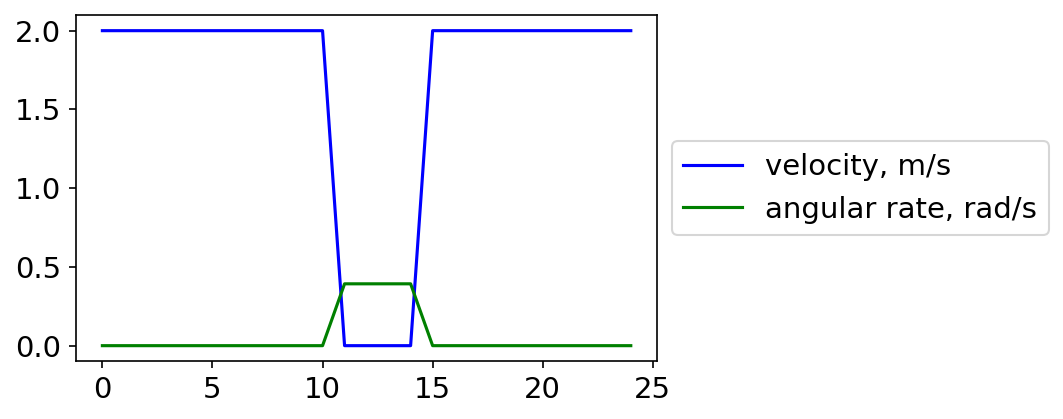

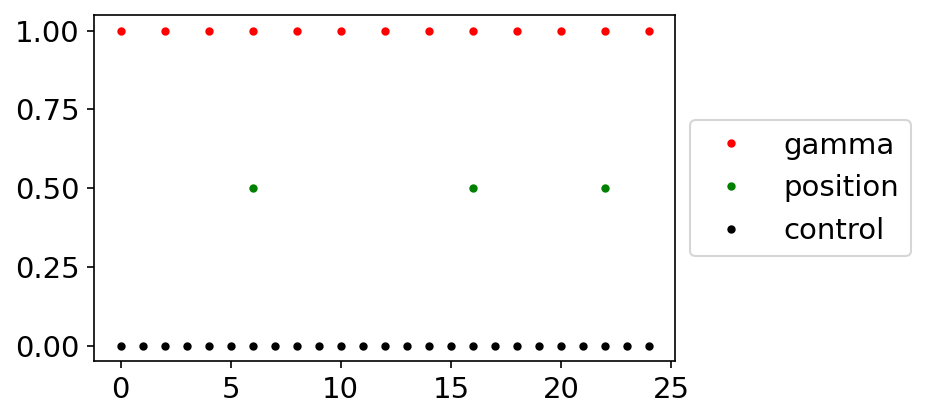

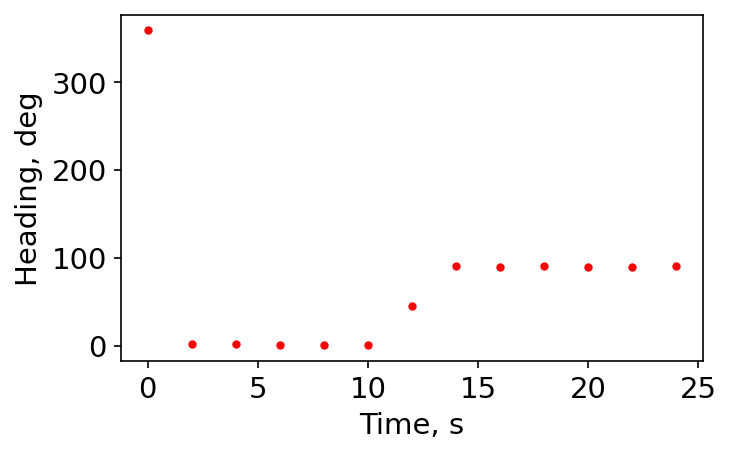

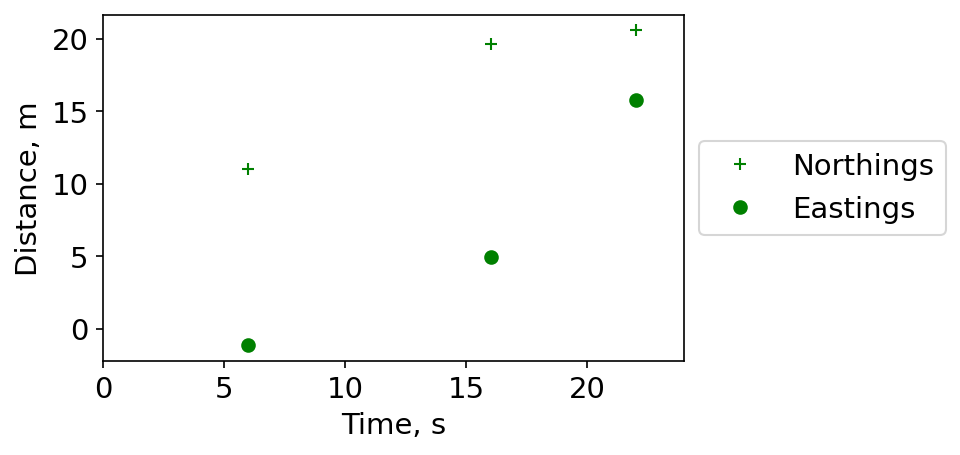

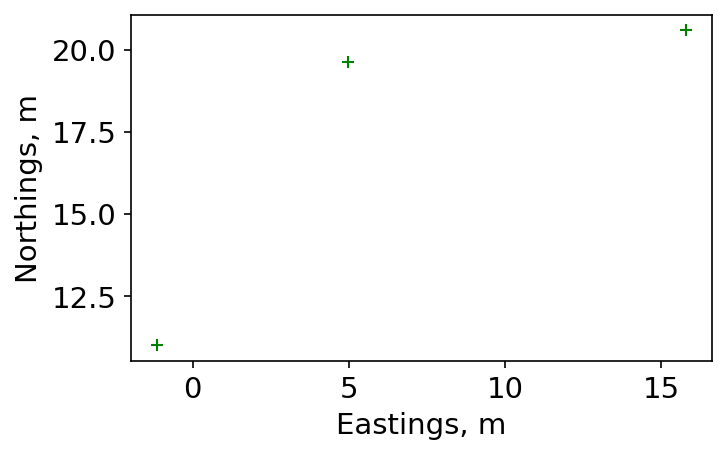

In [39]:
n_noise = 1
e_noise = 1

start = 0
end = 24

timestep = 1 #s
num_points = int( end / timestep )+1
t_list = np.linspace(start, end, num_points)
v_list = []
w_list = []
for i in range(len(t_list)):
    if t_list[i] <= 10:
        v_list.append(2)
        w_list.append(np.deg2rad(0.0))
    elif t_list[i] <= 14:
        v_list.append(0)
        w_list.append(np.deg2rad(90/4))
    else:
        v_list.append(2)
        w_list.append(np.deg2rad(0.0))   
    
T_u = l2m(t_list)
U = l2m([v_list,w_list])

plt.plot(T_u,U[:,0],'b-',label = 'velocity, m/s')
plt.plot(T_u,U[:,1],'g-',label = 'angular rate, rad/s')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)); plt.show()

# create some fake heading sensor readings
t_g_list = [0,2,4,6,8,10,12,14,16,18,20,22,24]
g_list = np.deg2rad([0,0,0,0,0,0,45,90,90,90,90,90,90]).tolist()
g_std = [np.deg2rad(1)] * len(g_list)

# create some fake position sensor readings
t_ne_list = [6,16,22]
n_list = [12,20,20]
e_list = [0,4,16]


n_std = [n_noise] * len(n_list)
e_std = [e_noise] * len(e_list)


# add noise to make things more realistic
for i in range(len(t_g_list)): 
    g_list[i]=(g_list[i]+np.random.normal(0, g_std[i])) % (2*np.pi)

    
measurement = Measurement()    
measurement_list = []
for i in range(len(t_ne_list)): 
    n_list[i]=n_list[i]+np.random.normal(0, n_std[i])
    e_list[i]=e_list[i]+np.random.normal(0, e_std[i])    
    
    # pack into our measurement class
    measurement.timestamp = t_ne_list[i]
    measurement.northings = n_list[i]
    measurement.eastings = e_list[i]
    measurement.northings_std = n_std[i]
    measurement.eastings_std = e_std[i]    
    measurement_list.append(copy.deepcopy(measurement))

    
#create our matrices
Z_ne = l2m([n_list,e_list])
T_ne = l2m(t_ne_list)
Z_g = l2m([g_list])
T_g = l2m(t_g_list)
G_std = l2m(g_std)
NE_std = l2m([n_std,e_std])

plt.plot(T_g,np.ones([len(T_g),1]),'r.',label='gamma')
plt.plot(T_ne,0.5*np.ones([len(T_ne),1]),'g.',label='position')
plt.plot(T_u,0.*np.ones([len(U),1]),'k.',label='control')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)); plt.show()

plt.plot(T_g,np.rad2deg(Z_g),'r.')
plt.xlabel('Time, s')
plt.ylabel('Heading, deg')
plt.show()

plt.plot(T_ne,Z_ne[:,0],'g+',label = 'Northings')
plt.plot(T_ne,Z_ne[:,1],'go',label = 'Eastings')
plt.xlabel('Time, s')
plt.ylabel('Distance, m')
plt.xlim([min(t_g_list),max(t_g_list)])
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)); plt.show()

plt.plot(Z_ne[:,1],Z_ne[:,0],'g+')
plt.xlabel('Eastings, m')
plt.ylabel('Northings, m')
plt.show()

## Wrap up

You should now:
- Understand how uncertainty modelling is achieved in the PF, and the impact of process and measurement noise parameters
- Be able to implement and apply a PF to a simple robotic scenario